# Wildfires in the US
## An Application of Geopandas, Rasterio, and Zonalstats

In [ ]:
import numpy
import matplotlib.pyplot as plt
import geopandas
import pyproj
import rasterio
import rasterstats

In [ ]:
data_dir = "C:/Users/jhtchns2/Box/ACE_592_SAE/Class_Examples/2_Images/"

The objective of this lecture is to demonstrate how to:
1. Read shape files.
2. Read and edit rasters.
3. Calculate zonal stats from:
    - A raster and a shape file
    - A shape file and a shape file


## Step 1: Reading shape files

### US States
Below is a geojson file of US states which is read into the dataframe as a geopandas dataframe

In [ ]:
# Creating the directory
state_file = data_dir + "us_states.json"
# Read in the geojson file.
country = geopandas.read_file(state_file)

What is a geopandas dataframe?

Essentially, it is the same as a pandas dataframe but with geographic methods. For example:
- It has a column called "geometry" which stores a `shapely` polygon or multi-polygon object.
- Has geographic information embedded (like the CRS).
- Default plot method makes a spatial plot.

In [ ]:
# Look at first 5 rows
country.head()

In [ ]:
# Print the type of the first row of the column "geometry"
print(type(country['geometry'][0]))
# Look at the actual geometry
country['geometry'][0]

In [ ]:
# Print the CRS of the shapefile
country.crs

In [ ]:
# Plot all of the polygons in the geodataframe
country.plot()

The frame is a bit big. What if we just wanted to look at the continental US?

Do what you would do usually with a Pandas dataframe!

In [ ]:
# Omit names in the list ['Alaska',"Hawaii","Puerto Rico"]
country = country[~country['NAME'].isin(["Alaska","Hawaii","Puerto Rico"])]
# Plot the new dataframe
country.plot(color="Grey")

These dataframes have very useful methods and attributes:
- `centroid`, which can extract the centroid from the shape.
- `to_crs()`, which can change the projection.
- `distance()`, which can tell you the distance between each row and a specific geometry.

Let's use these methods to find the distance between the Alabama centroid and every other state centroid.

In [ ]:
f,a = plt.subplots()
# PLot the dataframe on the axis a
country.plot(ax=a)
# Plot the centroids on that axis, colored white
country.centroid.plot(ax=a,color="white")

User warning! What did we do wrong?

In [ ]:
# Make a new dataframe, but projected to EPSG:4087
country_proj = country.to_crs(epsg=4087) # WGS 84 Equidistant Cylndrical
# Plot the new dataframe
country_proj.plot()

In [ ]:
# Print out the centroids
country_proj.centroid

In [ ]:
f,a = plt.subplots(figsize=(10,4))
# PLot the projected country dataframe
country_proj.plot(ax=a,zorder=1,color='gray')
# Plot the projected centroids (colored white)
country_proj.centroid.plot(ax=a,color="white",markersize=5)

The `distance` function works on a series, but requires a geometry object to be passed right to the function.

In [ ]:
# Find the centroid for Alabama
bama_cent = country_proj.centroid[0]
# Calculate the distance from each state centroid to the AL centroid
country_proj['bama_dist'] = country_proj.centroid.distance(bama_cent)/1000 # res is in meters, so converting to km
# Sort by AL distance, give me first 5 rows.
country_proj.sort_values("bama_dist").head()

In [ ]:
f,a = plt.subplots(figsize=(15,5))
#  Plot but with keywords
country_proj.plot(column="bama_dist", # the column I want to color the shapes by
                  ax=a, # Axis
                  legend=True, # Make a legend (color bar)
                  legend_kwds={'label': "Centroid Distance (km)"}); # Label the color bar
# Color the AL centroid red, make ms = 60
country_proj.centroid[:1].plot(color="C3",ax=a,markersize=60);
# Plot the other centroids, but white and smaller
country_proj.centroid[1:].plot(color="w",ax=a,markersize=5);
# Set the axis off
plt.axis("off");
# Give it a title
plt.title("State Centroid Distance from Alabama",fontsize=18)


### Notice:
Some cool functionality of the plotting function is that it has built in ability to do chloropleth maps very easily!

Going back to the code that I just wrote:

In [ ]:
f,a = plt.subplots(figsize=(7,6))
country_proj.plot(column="bama_dist", # This is the column for the value
                  ax=a,
                  cmap="copper", # Use the colormap copper
                  legend=True, #  Color bar
                  legend_kwds={'label': "Centroid Distance (km)", # label for colorbar
                               'orientation': "horizontal"}); # Make it horizontal
plt.axis("off");
plt.savefig("war_eagle_roll_tide.png",dpi=300)

## Wildfires
To demonstrate spatial joins, let's say we want to look at wildfires. NASA keeps a very [nice database on active fires](https://firms.modaps.eosdis.nasa.gov/active_fire/#firms-shapefile).

This one is a shapefile from NASA which was collected using their MODIS instrument. These are all the fires from October 20th 2020 until October 27th 2020.

In [ ]:
# Read in this shape file
fires = geopandas.read_file(data_dir+"MODIS_C6_USA_contiguous_and_Hawaii_7d.shp")

Before we go plotting them together, let's do a projection check.

#### Projection check

In [ ]:
# Are they equal?
country.crs == fires.crs

We're good to go!

Notice that instead of "polygons," we have "point" objects.

If we plot them on top of each other we get this:

In [ ]:
f,a = plt.subplots(figsize=(10,10))
# This is plotting the states
country.plot(ax=a,color="grey")
# This is plotting the fires
fires.plot(color="C3",markersize=10,ax=a)

So notice that our fire data is in Mexico as well as Canada. How do we only look at fires in the US?

Intuitively, we look for the overlap. Restricting a shape file based on another shapefile is called __clipping__.

Geopandas has a great clipping function: 

In [ ]:
print(fires.shape)

print(geopandas.clip(fires,country).shape)

The first argument is the thing you want clipped, the second argument is the mask used to clip it.

So it looks like clipping got rid of about 500 fires.

In [ ]:
# The clip function's two arguments are
# The thing to be clipped
# The mask used to clip it
fires = geopandas.clip(fires,country)

f,a = plt.subplots(figsize=(10,10))
country.plot(ax=a,color="grey")
fires.plot(color="C3",markersize=10,ax=a);

Using the geopandas plotting function, we can actually color the dots according to one of the variables.

We will do it here according to the column "brightness."

In [ ]:
f,a = plt.subplots(figsize=(10,5))
# Plot the country
country.plot(ax=a,color="grey")
# Clip fires to that country
clipped = geopandas.clip(fires,country)
# PLot 
clipped.plot(markersize=10, # set the markersize
             ax=a, # plot on this axis
             column='BRIGHTNESS', # plot using the brightness variable
             cmap="OrRd_r", # Use the colormap OrRd (but reverse)
             scheme='quantiles', # Chop it up on quantiles
             legend=True); # Legend

### What is a spatial join?
Spatial joining is essentially executing a merge between two shapefiles. Instead of using indexes it uses their spatial positions.

For example, what if we wanted to count the number of fires in a given state?

In [ ]:
# The sjoin arguments are:
# Left shapefile
# Right shapefile
fires_w_state = geopandas.sjoin(fires,\
                                country,\
                                how='left')

state_w_fires = geopandas.sjoin(fires,\
                                country,\
                                how='right')

fires_w_state.shape, state_w_fires.shape


They look about the same size, what was the difference between the left and right merge?

In [ ]:
fires_w_state.head().geometry, \
state_w_fires.head().geometry

With spatial joins in geopandas dataframes, only one set of geometry will be retained. So make sure you understand how you are merging things!

Both of these dataframes could be useful in different ways.

In [ ]:
f,a = plt.subplots(figsize=(10,10))
# Plot the country
country.plot(color='gray',ax=a)
# Plot the fires with the column "CENSUSAREA"
fires_w_state.plot(column="CENSUSAREA",ax=a)
# Title it
plt.title("Fires Colored by Census Area")

Let's get a count of fires per state.

In [ ]:
# Value count the number of times each state name appears
state_w_fires.value_counts("NAME").head()

In [ ]:
# This function groups by name, counts the number of rows, reset index
state_fire_counts = state_w_fires.groupby("NAME")['index_left'].count().reset_index()
# This line names the columns "NAME" and "fire_name"
state_fire_counts.columns = ["NAME","fire_number"]
# Print first 5 rows
state_fire_counts.head()

In [ ]:
# Merge fire counts into the state shapefile.
country = country.merge(state_fire_counts,how='left',on="NAME")

In [ ]:
f,a = plt.subplots(figsize=(20,10))

country.plot(column="fire_number", # Color by fire number
             ax=a, # On the a axis
             cmap="OrRd", # Use OrRd
            legend=True) # Make a colorbar
# Plot the states, but with no facecolor, and black edges
country.plot(ax=a,facecolor='none', edgecolor='black')


California and Colorado are clear outliers, could use the quantile method instead.

In [ ]:
f,a = plt.subplots(figsize=(10,10))

country.plot(column="fire_number", # Color using fire number
             ax=a, # On this axis
             cmap="OrRd", # OrRd colormap
             scheme="quantiles", # But use quantiles!
             legend=True) # Colorbar

# Plot empty states (with no color)
country.plot(ax=a,facecolor='none', edgecolor='black')

### Dissolves

What if we wanted to merge polygons into one polygons? This is called a __dissolve__.

Geopandas make this very easy.

In [ ]:
# Make new column, "USA" for every row
country['country'] = "USA"
# The arguments of dissolve are:
# by: which variable do you want to dissolve on?
# aggfunc: how you want to aggregate the other columns
dissolved = country.dissolve(by="country",aggfunc="sum")
# plot, make the edges black
dissolved.plot(edgecolor="black")

Or do it based on something arbitrary:

In [ ]:
# the last 20 rows, for the column country, put "Aot USA"
country.loc[30:,"country"] = "Not USA"
# Dissolve again on the variable 
dissolved = country.dissolve(by="country",aggfunc="sum")
# plt 
dissolved.plot(edgecolor="black")

So now we have dissolved multiple states into one polygon. Dissolves are useful when you want to change the level of analysis.

## Step 2: Read in rasters

 Let's read in a raster file, in this case annual precipitation data from 2017 from [PRISM](https://prism.oregonstate.edu/recent/), a great source of historical weather data. 
 
 The package for reading in raster files is called `rasterio`

In [ ]:
import rasterio
# This is the file, rainfall for 2017 (4km grid)
raster_file = "PRISM_ppt_stable_4kmM3_2017_bil.bil"
# Rasterio open function
raster = rasterio.open(data_dir+raster_file)

In [ ]:
# Read raster (makes it a numpy array), look at first channel (or band)
plt.imshow(raster.read()[0,:,:])

In this case, the file format is a .bil not a .tif

#### Projection check:

In [ ]:
# Check the projections
raster.crs==country_proj.crs

What are the CRSs?

In [ ]:
#raster.crs, \
country_proj.crs

So this is not what our shapefile currently is because we reprojected it...

Two ways we can go about this:
1. Reproject the raster file to match the shapefile (harder).
2. Reproject the shapefile to match the raster (easier).

It takes only one line to reproject geopandas dataframes, but much more code to do the same for rasterio. Here I'll demonstrate the raster way.

So what is the raster object anyway?

In [ ]:
raster.width,\
raster.height,\
raster.bounds

Notice that it is almost the same as a numpy array but it embeds geographic information. The function `read` will transform it into a numpy array.

In [ ]:
type(raster.read()),\
raster.read().shape

How can we use this info to translate it into a different coordinate system?

In [ ]:
raster.transform

Each raster contains an "affine transformation" which translates the pixel coordinates into geographic coordinates.

According to the docs, the above are coefficients to this equation:

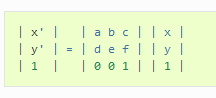

### Reprojecting a Raster

Essentially, we need to create a function that translates one "transformation" into another. We need to take the measurements of the first system and create a function that translates into a new system.

Now let's look at some code from [this question](https://gis.stackexchange.com/questions/337528/rasterio-reprojection-doesnt-seem-to-work]):

In [ ]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas
# What is the source file?
src_file = raster_file
# Name a destination file
dst_file = 'ppt_reproj.tif'
# Destination CRS
dst_crs = rasterio.crs.CRS.from_dict({'init': 'EPSG:4087'})

The following code does the reprojection... but what is it actually doing?

In [ ]:
with rasterio.open(data_dir+src_file) as src: 
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds) 
    kwargs = src.meta.copy() 
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })
    with rasterio.open(dst_file, 'w', **kwargs) as dst: 
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)


### Discuss in groups!

In [ ]:
# Open the file I just wrote
raster = rasterio.open("./ppt_reproj.tif")
# Look at the CRS
raster.crs

In [ ]:
# Read the first band
ppt = raster.read(1)
# Look at it
ppt

So now we have a Numpy array. Here's what it looks like plotted:

In [ ]:
# Plot it with the "Blues" colormap
plt.imshow(ppt,cmap="Blues", vmin=-100,vmax=700)

##### Reminder

the difference between a raster and a usual numpy array is that rasters are georeferenced. So rasters have info like this:

In [ ]:
# print the CRS
raster.crs

In [ ]:
# Print the bounds
raster.bounds

But reading it as a numpy array it no longer has this data, it's simply a matrix.

To understand why this important, lets look at what it would take to "clip" a raster to a specific state like Illinois...

### Clipping and Editing Rasters

What if we only wanted a raster of Illinois and not the entire US? We would have to essentially "mask" the raster just we like would usually mask an array, but this time omit everything outside of the Illinois border.

The way this works:
1. Find the Illinois coordinates
2. Use the rasterio "mask" function to get back an edited array.
    - NOTE: when we do this, the resulting array LOSES its geographic data, so we have to write it back with the geographic information.
3. Re-embed geographic data
4. Write out clipped raster
5. Read it back in

#### 1. Find the Illinois Coordinates
Each geopandas geometry object contains the coordinates that the rasterio function wants.

In [ ]:
import json
# Subset the country df to just Illinois
illinois_row = country_proj[country_proj.NAME=="Illinois"]
# Load the json file that is the geometry
illinois_json = json.loads(illinois_row['geometry'].to_json())
# Access the geometry inside the dictionary
illinois_json['features'][0]['geometry']

This is the data we need to load into the function, so we can make a fancy function (this is from [this documentation](https://automating-gis-processes.github.io/CSC18/lessons/L6/clipping-raster.html)):

Essentially, this function takes a GeoDataFrame and extracts the coordinates it needs.

In [ ]:
def getFeatures(gdf):
    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
    import json
    return [json.loads(gdf.to_json())['features'][0]['geometry']]
# Get the one row that is Illinois
IL_row = country_proj[country_proj.NAME=="Illinois"]
# PAss it through this function
IL_coords = getFeatures(IL_row)

What they look like plotted:

In [ ]:
# Transform those coordinates into a numpy array
coords = np.array(IL_coords[0]['coordinates'][0])
# Plot the x axis and y axis
plt.plot(coords[:,0],coords[:,1],color='black')

Rasterio has its own `mask` function that can help us with this. It takes the raster object as the first argument and our coordinates as the second:

In [ ]:
from rasterio.mask import mask
# The two arguments for the mask function are:
# The thing you are masking
# The shape used to mask it
img_out, img_transform = mask(raster,IL_coords)

Plotted it looks like this:

In [ ]:
# Show the first channel of img_out
plt.imshow(img_out[0],cmap="Blues")

So now we have just Illinois. But notice now that the indices dont have anything to do with geo-coordinates. How do we get this info back?

The second output of the function "mask" is the directions on how to translate them back:

In [ ]:
img_transform

To make this a raster again, we can write it back as a raster while re-embedding the metadata

In [ ]:
# First copy the metadata
out_meta = raster.meta.copy()
# Assign the new metadata
out_meta['height'] = img_out.shape[1]
out_meta['width'] = img_out.shape[2]
out_meta['transform'] = img_transform
# Open a new file, write it to that file
with rasterio.open("./IL_PPT.tif", "w", **out_meta) as dest:
    dest.write(img_out)

In [ ]:
# Open it
IL_raster = rasterio.open("./IL_PPT.tif")

In [ ]:
IL_raster.read(1)

In [ ]:
from rasterio.plot import show
# Make a big plot
fig, ax = plt.subplots(figsize=(15, 15))
# Show the Illinois raster
rasterio.plot.show(IL_raster, ax=ax,cmap="Blues")
# Show the rest of the country (with no facecolor and edge color black)
country_proj.plot(ax=ax, facecolor='none', edgecolor='black')

Nice!

With this technique, a huge upside is that __we can edit rasters just like numpy arrays__ as long as we write the data back with the right metadata.

For example, what if we wanted a raster of zeros and ones indicating if rainfall hits a certain threshhold, for example the state average?

### Making a New Raster

In [ ]:
import pandas as pd
# Flattening the array, making it a series
IL_vals = pd.Series(IL_raster.read(1).flatten())
# Leave out the background value, calculate the mean 
IL_avg = IL_vals[IL_vals!=-9999].mean()

In [ ]:
IL_avg

Do it like this: 

In [ ]:
# Read in the raster (as a numpy array)
IL_r_vals = IL_raster.read(1)

In [ ]:
# Make a binary array (with a new axis)
binary_array = (IL_r_vals>IL_avg)[np.newaxis,:,:]
# conver to a number
img_out = binary_array.astype(np.float32)

__NOTE:__ A couple of things happened up there:

`img_out = (IL_r_vals>IL_avg)[np.newaxis,:,:].astype(np.float32)`

1. We made a boolean array by coding "True" if the rainfall was above the average
2. We added an axis so the array is three dimensions using "np.newaxis"; raster always are three dimensional arrays, the first dimension being the band and the second and third being the rows and the columns. We need to put a "band" dimension into any array before it can be written to raster.
3. We converted the "booleans" to float32 to make it play nice with Rasterio

Now change the metadata

In [ ]:
# Copy the metadata
out_meta = IL_raster.meta.copy()
# Write new metadata
out_meta['height'] = img_out.shape[1]
out_meta['width'] = img_out.shape[2]
out_meta['transform'] = img_transform
# Write out to "example.tif"
with rasterio.open("./example.tif", "w", **out_meta) as dest:
    dest.write(img_out)

In [ ]:
#Read in that example
IL_raster = rasterio.open("./example.tif")

fig, ax = plt.subplots(figsize=(3, 5))
# Plot the new raster
rasterio.plot.show(IL_raster, ax=ax,cmap="Blues")
# Plot the country
country_proj.plot(ax=ax, facecolor='none', edgecolor='black')
# Limit the window to just Illinois
plt.xlim(-1.03*10**7,-.97*10**7)
plt.ylim(4.1*10**6,4.8*10**6)

### The above is an important skill for Homework 2

## Step 3: Zonal Statistics

The next step is doing some basic zonal statistics. Zonal statistics are one way to summarize a raster file using a vector file.

Here we will find the average rainfall for that year for all the counties in Illinois.

### Country-wide

First, let's start with the whole country.

The package "rasterstats" is very convenient for this. Its function "zonal_stats" takes two arguments:
1. Shapefile path, polygon object, or geopandas dataframe
2. Raster file path, or a numpy array if you supply "transform" to tell it coordinates.

In [ ]:
from rasterstats import zonal_stats
# The two arguments for this function are
#  1. The shapefile
#  2. The raster file (from disk)
zonal_stats(country_proj, "./ppt_reproj.tif")

Returns a list of dictionaries that can be made into a dataframe:

In [ ]:
import pandas as pd

# Run zonal stats 
stats = zonal_stats(country_proj, "./ppt_reproj.tif")
# Wrap the output as a dataframe
rain_stats = pd.DataFrame(stats)
# Look at the shape
rain_stats.shape

In [ ]:
rain_stats

Notice there are 49 rows, which is the same as `country_proj`:

In [ ]:
country_proj.shape

This function calculates stats and returns the stats unlabeled but in the same order as the input shapefile.

This means we just concatenate our dataframes:

In [ ]:
# Rename the columns to have "rain" in front of them
rain_stats.columns = ["rain_"+x for x in rain_stats.columns]
# Note: you need to make the indices match first
rain_stats.index = country_proj.index
# Concatenating them (on axis=1)
country_rain = pd.concat([country_proj,rain_stats],axis=1)

In [ ]:
country_rain.head()

In [ ]:
f,a = plt.subplots(figsize=(10,3))
# Plot the geodataframe
country_rain.plot(column="rain_mean", # Use the average rainfall
                  cmap="Blues", # Colormap set to blues
                  legend=True, # Use a color bar
                  ax=a, # Put it on axis "a"
                  edgecolor="black") # color the edges black

### With counties

In [ ]:
# Read in a county shapefile
counties = geopandas.read_file(data_dir+"us_counties_2017.shp")

# Reproject to our country shapefile
counties = counties.to_crs(country_proj.crs)

counties.plot()

Subset to Illinois:

In [ ]:
# Subset this data to FIPS state code 17 
IL_counties = counties[counties['STATEFP'] == "17"]
# Plot it
IL_counties.plot(edgecolor="black",facecolor="none")

Now do the rasterstats as before.

In [ ]:
from rasterstats import zonal_stats
# Reminder: the inputs to this function are
# 1. The shapefile
# 2. The rasterfile
zonal_stats(IL_counties, "./ppt_reproj.tif")

In [ ]:
# Calculate the stats, convert to df
county_rain_stats = pd.DataFrame(zonal_stats(IL_counties, "./ppt_reproj.tif"))
# Rename the columns
county_rain_stats.columns = ["rain_"+x for x in county_rain_stats.columns]

# Note: you need to make the indices match first
county_rain_stats.index = IL_counties.index
# Concatenate
IL_counties = pd.concat([IL_counties,county_rain_stats],axis=1)

In [ ]:
f,a = plt.subplots(figsize=(6,3))
# Plot
IL_counties.plot(column="rain_mean", # The column we are visualizing
                 cmap="Blues", # the color map
                 legend=True, # the color bar
                 ax=a, # the axis we are plotting on
                 edgecolor="black") # edge color set to black

Simple as that!